# 02 - Classical Models: Phishing URL Detection

Second notebook in the project (see the repository `README.md`).
Notebook 01 audited the dataset for leakage and saved the safe feature
list to `data/01_feature_columns.json`. Here we:

1. **engineer new features** from the raw URL / Domain strings — the
   project's "twist," targeting signal the shipped columns don't encode
2. train three classifiers (Logistic Regression, Random Forest, XGBoost)
   on the leakage-clean feature set
3. handle the (mild, ~57/43) class imbalance and test whether SMOTE helps
4. tune the strongest model and read off feature importance
5. check whether a handful of top features match the full model
6. add a **cost-sensitive decision layer** and pick a business-relevant
   operating point

**Label orientation (important):** the raw `label` is
`1 = legitimate, 0 = phishing`. We model **phishing as the positive
class** (`y = 1 - label`) so precision, recall, and PR-AUC all describe
*catching phishing*.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from rapidfuzz import process
from rapidfuzz.distance import Levenshtein
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    RandomizedSearchCV,
    StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [3]:
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "phiusiil.csv")
manifest = json.loads((DATA_DIR / "01_feature_columns.json").read_text())

clean_features = manifest["clean_numeric_features"]
print(f"rows: {len(df):,}")
print(f"clean features from notebook 01: {len(clean_features)}")

rows: 235,795
clean features from notebook 01: 49


## 1. Engineered features

PhiUSIIL already ships lexical ratios and page-content counts. To add
something genuinely new, we build four signals from the raw `URL` /
`Domain` strings (held out of the clean set as identifiers) that those
columns don't already encode:

- **`url_entropy` / `domain_entropy`** — character-level Shannon entropy.
  Randomly generated (DGA-style) domains tend to look more random.
- **`brand_distance`** — the smallest normalized edit distance from any
  significant domain label to a curated brand list. A domain that is
  *close but not equal* to a known brand is the classic typosquatting
  signal (e.g. `paypa1`, `paypal-secure`).
- **`is_punycode`** — the domain uses `xn--` (IDN homograph attacks).
- **`is_shortener`** — the registered domain is a known URL shortener.

In [4]:
def shannon_entropy(s):
    if not s:
        return 0.0
    counts = np.unique(list(s), return_counts=True)[1]
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())


SUFFIX_STOP = {
    "www",
    "com",
    "org",
    "net",
    "edu",
    "gov",
    "co",
    "uk",
    "io",
    "de",
    "ru",
    "info",
    "biz",
    "app",
    "xyz",
    "online",
    "site",
    "web",
}
SHORTENERS = {
    "bit.ly",
    "tinyurl.com",
    "goo.gl",
    "t.co",
    "ow.ly",
    "is.gd",
    "buff.ly",
    "adf.ly",
    "rebrand.ly",
    "cutt.ly",
    "shorturl.at",
}
BRANDS = [
    "paypal",
    "apple",
    "microsoft",
    "google",
    "amazon",
    "facebook",
    "instagram",
    "netflix",
    "linkedin",
    "whatsapp",
    "outlook",
    "office365",
    "chase",
    "wellsfargo",
    "bankofamerica",
    "citibank",
    "hsbc",
    "barclays",
    "americanexpress",
    "capitalone",
    "santander",
    "visa",
    "mastercard",
    "coinbase",
    "binance",
    "blockchain",
    "metamask",
    "dropbox",
    "adobe",
    "yahoo",
    "gmail",
    "icloud",
    "spotify",
    "steam",
    "roblox",
    "twitter",
    "tiktok",
    "snapchat",
    "ebay",
    "walmart",
    "target",
    "fedex",
    "ups",
    "dhl",
    "usps",
    "irs",
    "hmrc",
    "docusign",
    "onedrive",
    "zoom",
    "twitch",
    "discord",
    "telegram",
    "reddit",
    "github",
    "wordpress",
    "shopify",
    "stripe",
    "venmo",
    "zelle",
    "cashapp",
    "revolut",
    "aliexpress",
    "alibaba",
    "samsung",
    "xfinity",
    "verizon",
    "tmobile",
    "vodafone",
    "booking",
    "airbnb",
    "uber",
    "lyft",
    "doordash",
    "instacart",
]


def domain_labels(domain):
    return [
        p
        for p in domain.lower().split(".")
        if p not in SUFFIX_STOP and len(p) >= 3
    ]


def registered_domain(domain):
    d = domain.lower()
    return d[4:] if d.startswith("www.") else d

In [5]:
dom = df["Domain"].astype(str)

df["url_entropy"] = df["URL"].astype(str).map(shannon_entropy)
df["domain_entropy"] = dom.map(shannon_entropy)
df["is_punycode"] = dom.str.contains("xn--").astype(int)
df["is_shortener"] = dom.map(registered_domain).isin(SHORTENERS).astype(int)

# brand_distance: min normalized Levenshtein from any significant domain
# label to a brand. Compute once per unique label (fast in C), then map.
labels_per_row = dom.map(domain_labels)
unique_labels = sorted({lab for labs in labels_per_row for lab in labs})
dist = process.cdist(
    unique_labels, BRANDS, scorer=Levenshtein.normalized_distance
)
label_min = dict(zip(unique_labels, dist.min(axis=1)))


def brand_distance(labs):
    return min((label_min[x] for x in labs), default=1.0)


df["brand_distance"] = labels_per_row.map(brand_distance).astype(float)

engineered = [
    "url_entropy",
    "domain_entropy",
    "brand_distance",
    "is_punycode",
    "is_shortener",
]
print(df[engineered].describe().round(3).to_string())

       url_entropy  domain_entropy  brand_distance  is_punycode  is_shortener
count   235795.000      235795.000      235795.000   235795.000    235795.000
mean         3.961           3.472           0.625        0.001         0.002
std          0.315           0.401           0.116        0.026         0.049
min          2.309           0.722           0.000        0.000         0.000
25%          3.763           3.203           0.571        0.000         0.000
50%          3.929           3.471           0.636        0.000         0.000
75%          4.101           3.720           0.700        0.000         0.000
max          5.335           4.975           1.000        1.000         1.000


### Do the engineered features separate the classes?

A quick look before modeling — medians by class and the distributions of
the three continuous features. (Reminder: `label` 0 = phishing.)

                phishing_median  legit_median
url_entropy               4.060         3.866
domain_entropy            3.625         3.423
brand_distance            0.625         0.667
is_punycode               0.000         0.000
is_shortener              0.000         0.000


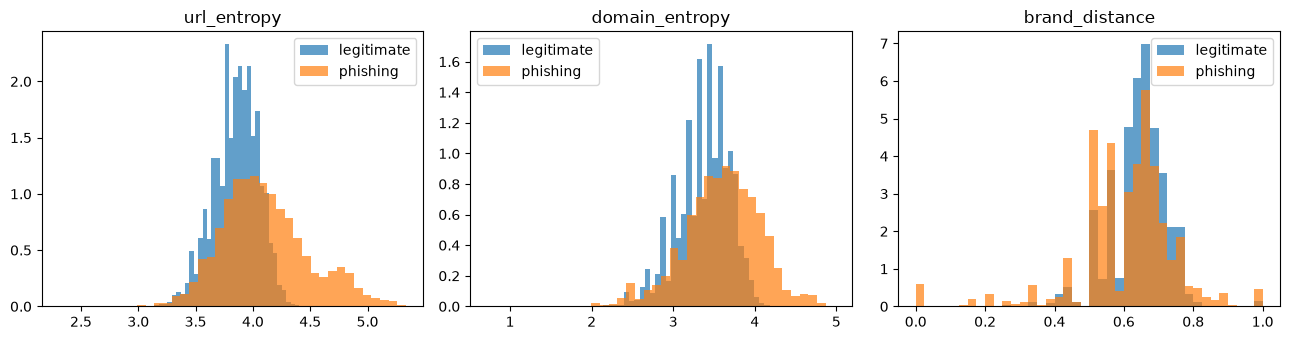

In [6]:
phish = df["label"] == 0
by_class = pd.DataFrame(
    {
        "phishing_median": df.loc[phish, engineered].median(),
        "legit_median": df.loc[~phish, engineered].median(),
    }
)
print(by_class.round(3).to_string())

cont = ["url_entropy", "domain_entropy", "brand_distance"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, cont):
    ax.hist(
        df.loc[~phish, col],
        bins=40,
        alpha=0.7,
        density=True,
        color="tab:blue",
        label="legitimate",
    )
    ax.hist(
        df.loc[phish, col],
        bins=40,
        alpha=0.7,
        density=True,
        color="tab:orange",
        label="phishing",
    )
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 2. Assemble the modeling frame

Following notebook 01's manifest: drop duplicate URLs (so the same URL
can't land in both train and test), model phishing as the positive class,
and split with a **domain-grouped** 80/20 split so every row of a domain
stays on one side.

In [7]:
features = clean_features + engineered

before = len(df)
model_df = df.drop_duplicates(subset="URL").reset_index(drop=True)
print(f"dropped {before - len(model_df):,} duplicate-URL rows")

X = model_df[features]
y = 1 - model_df["label"]  # 1 = phishing (positive class)
groups = model_df["Domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"train: {len(X_train):,}   test: {len(X_test):,}")
print(f"phishing rate  train={y_train.mean():.3f}  test={y_test.mean():.3f}")

dropped 425 duplicate-URL rows
train: 188,738   test: 46,632
phishing rate  train=0.428  test=0.423


## 3. Model roster

Three classifiers, all treating phishing as the positive class:

| Model | Why |
|---|---|
| Logistic Regression (class-weighted) | interpretable linear baseline |
| Random Forest (class-weighted) | non-linear + feature importance |
| XGBoost (`scale_pos_weight`) | strongest tabular model |

We report accuracy, precision, recall, F1, ROC-AUC, and **PR-AUC**
(`average_precision`) — the last is the more informative summary under
class imbalance.

In [8]:
def xgb(**kw):
    params = dict(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    params.update(kw)
    return XGBClassifier(**params)


def evaluate(name, model, X_te, y_te):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "pr_auc": average_precision_score(y_te, proba),
    }


n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())

models = {
    "LogReg": Pipeline(
        [
            ("scale", StandardScaler()),
            (
                "clf",
                LogisticRegression(max_iter=1000, class_weight="balanced"),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": xgb(scale_pos_weight=n_neg / n_pos),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    rows.append(evaluate(name, model, X_test, y_test))

results = pd.DataFrame(rows).set_index("model")
print(results.round(4).to_string())

              accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                             
LogReg          0.9995     0.9995  0.9993  0.9994      1.0     1.0
RandomForest    0.9999     0.9999  0.9998  0.9999      1.0     1.0
XGBoost         0.9999     1.0000  0.9998  0.9999      1.0     1.0


### Confusion matrices

Rows are the true class, columns the prediction (phishing = the class we
care about catching).

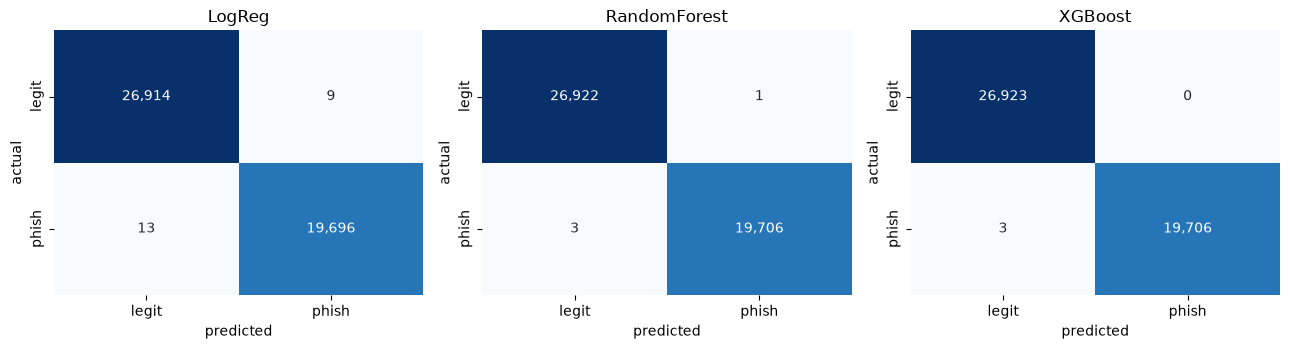

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["legit", "phish"],
        yticklabels=["legit", "phish"],
    )
    ax.set_title(name)
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
plt.tight_layout()
plt.show()

## 4. Class-imbalance handling

The imbalance here is **mild** (~57/43), so we start with the cheap
option — `scale_pos_weight` — and treat SMOTE as an explicit ablation,
not a default. We compare three setups on the same XGBoost model:
no balancing, class weighting, and SMOTE oversampling.

In [10]:
ablation = {
    "none": xgb(),
    "scale_pos_weight": xgb(scale_pos_weight=n_neg / n_pos),
    "SMOTE": ImbPipeline(
        [
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("clf", xgb()),
        ]
    ),
}

rows = []
for name, model in ablation.items():
    model.fit(X_train, y_train)
    rows.append(evaluate(name, model, X_test, y_test))

print(pd.DataFrame(rows).set_index("model").round(4).to_string())

                  accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                                 
none                0.9999        1.0  0.9998  0.9999      1.0     1.0
scale_pos_weight    0.9999        1.0  0.9998  0.9999      1.0     1.0
SMOTE               1.0000        1.0  0.9999  0.9999      1.0     1.0


The three rows are nearly identical: on mild imbalance with an
already-separable feature set, resampling buys essentially nothing (and
SMOTE synthesizes points among correlated tabular features, a known
overfitting risk). We keep `scale_pos_weight` as the cheap default.

## 5. Tune the strongest model

`RandomizedSearchCV` over XGBoost, scored on **PR-AUC**
(`average_precision`) and cross-validated with `StratifiedGroupKFold` so
domains never straddle a fold boundary during tuning either.

In [11]:
cv = StratifiedGroupKFold(n_splits=5)
param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.03, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}
search = RandomizedSearchCV(
    xgb(scale_pos_weight=n_neg / n_pos),
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train, groups=groups_train)
best = search.best_estimator_

print("best params:", search.best_params_)
print(f"CV PR-AUC: {search.best_score_:.4f}")
tuned = evaluate("XGBoost (tuned)", best, X_test, y_test)
print(pd.DataFrame([tuned]).set_index("model").round(4).to_string())

best params: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
CV PR-AUC: 1.0000
                 accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                                
XGBoost (tuned)    0.9999        1.0  0.9998  0.9999      1.0     1.0


## 6. Feature importance

Two views: XGBoost's built-in gain importance, and model-agnostic
**permutation importance** (drop in PR-AUC when a feature is shuffled),
computed on a test-set sample. We specifically check where the four
engineered features land.

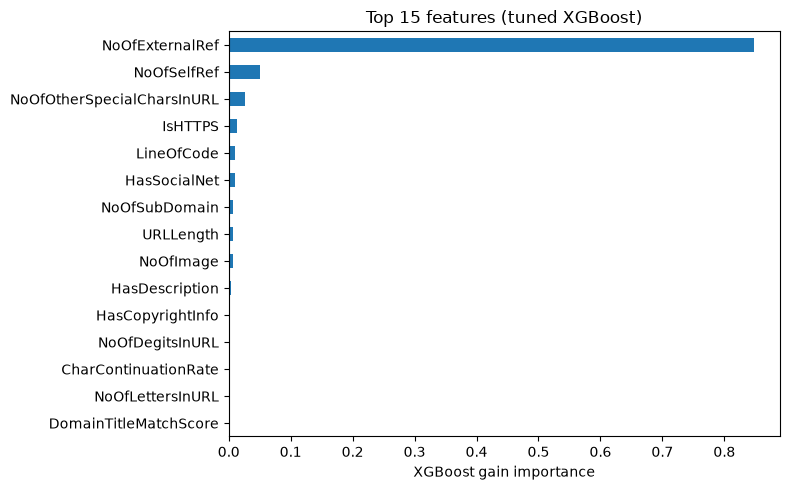

engineered-feature ranks (of 54 features):
  url_entropy      rank 22   gain 0.0003
  domain_entropy   rank 35   gain 0.0000
  brand_distance   rank 29   gain 0.0001
  is_punycode      rank 42   gain 0.0000
  is_shortener     rank 54   gain 0.0000


In [12]:
importances = pd.Series(best.feature_importances_, index=features).sort_values(
    ascending=False
)

plt.figure(figsize=(8, 5))
importances.head(15)[::-1].plot.barh(color="tab:blue")
plt.xlabel("XGBoost gain importance")
plt.title("Top 15 features (tuned XGBoost)")
plt.tight_layout()
plt.show()

print(f"engineered-feature ranks (of {len(features)} features):")
for f in engineered:
    rank = int(importances.index.get_loc(f)) + 1
    print(f"  {f:16s} rank {rank:2d}   gain {importances[f]:.4f}")

In [13]:
sample = X_test.sample(min(20000, len(X_test)), random_state=RANDOM_STATE)
perm = permutation_importance(
    best,
    sample,
    y_test.loc[sample.index],
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_imp = pd.Series(perm.importances_mean, index=features)
print("top 10 by permutation importance (PR-AUC drop):")
print(perm_imp.sort_values(ascending=False).head(10).round(4).to_string())

top 10 by permutation importance (PR-AUC drop):
IsHTTPS                       0.0011
LineOfCode                    0.0001
NoOfSubDomain                 0.0000
NoOfSelfRef                   0.0000
LetterRatioInURL              0.0000
LargestLineLength             0.0000
NoOfOtherSpecialCharsInURL    0.0000
NoOfExternalRef               0.0000
NoOfDegitsInURL               0.0000
NoOfImage                     0.0000


## 7. Does a handful of features match the full model?

The assignment intro calls this out as the model of a good result: if a
model using only the top-K features nearly matches the full model, that's
an actionable finding — a production filter could collect far fewer
signals per URL. We retrain XGBoost on just the top 8 features.

In [14]:
K = 8
top_k = importances.head(K).index.tolist()
print(f"top {K} features: {top_k}")

simple = xgb(scale_pos_weight=n_neg / n_pos)
simple.fit(X_train[top_k], y_train)
simple_res = evaluate(f"XGBoost (top {K})", simple, X_test[top_k], y_test)

compare = pd.DataFrame([tuned, simple_res]).set_index("model")
print(compare.round(4).to_string())

top 8 features: ['NoOfExternalRef', 'NoOfSelfRef', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'LineOfCode', 'HasSocialNet', 'NoOfSubDomain', 'URLLength']
                 accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                                
XGBoost (tuned)    0.9999      1.000  0.9998  0.9999      1.0     1.0
XGBoost (top 8)    0.9994      0.999  0.9995  0.9993      1.0     1.0


## 8. Cost-sensitive decision layer

Accuracy near the ceiling hides the real design question: **where do you
want the few remaining errors to fall?** That depends on the cost of each
error type, which is asymmetric for phishing:

- A **false negative** (phishing let through) risks credential theft /
  fraud — we set its cost an order of magnitude higher, anchored loosely
  to public breach-cost figures.
- A **false positive** (legitimate site blocked) costs user friction and
  support load — an illustrative estimate, not a sourced figure.

We sweep the decision threshold and pick the operating point that
minimizes expected cost per 1,000 URLs, instead of the default 0.5.

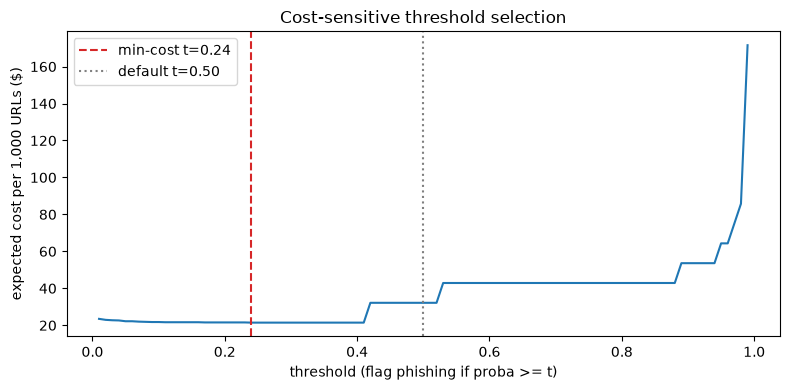

min-cost threshold: 0.24  ($21.44 per 1k) vs $32.17 at default 0.5


In [15]:
# Illustrative per-event costs (see markdown above).
COST_FN = 500.0
COST_FP = 5.0

proba = best.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
n = len(y_test)


def cost_per_1k(t):
    pred = (proba >= t).astype(int)
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    return (COST_FN * fn + COST_FP * fp) / n * 1000


cost_curve = np.array([cost_per_1k(t) for t in thresholds])
best_t = float(thresholds[cost_curve.argmin()])

plt.figure(figsize=(8, 4))
plt.plot(thresholds, cost_curve, color="tab:blue")
plt.axvline(best_t, color="tab:red", ls="--", label=f"min-cost t={best_t:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="default t=0.50")
plt.xlabel("threshold (flag phishing if proba >= t)")
plt.ylabel("expected cost per 1,000 URLs ($)")
plt.title("Cost-sensitive threshold selection")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"min-cost threshold: {best_t:.2f}  "
    f"(${cost_curve.min():.2f} per 1k) vs "
    f"${cost_per_1k(0.5):.2f} at default 0.5"
)

## 9. Business metric: it depends on the deployment

There is no single "right" metric — it follows the deployment scenario:

- A **browser warning system** (Google Safe Browsing style) is
  precision-first: wrongly blocking a legitimate site is highly visible,
  so it accepts lower recall for very high precision.
- A **mail/endpoint gateway** that quarantines silently is recall-first:
  a missed phishing email reaching an inbox is the expensive outcome.

We report both operating points, plus a **3-tier allow / warn / block**
policy — closer to how real filters behave than one binary cutoff.

In [16]:
prec, rec, thr = precision_recall_curve(y_test, proba)


def operating_point(target, mode):
    metric = prec[:-1] if mode == "precision" else rec[:-1]
    other = rec[:-1] if mode == "precision" else prec[:-1]
    ok = metric >= target
    if not ok.any():
        return None
    idx = np.where(ok)[0]
    pick = idx[np.argmax(other[idx])]
    return thr[pick], prec[pick], rec[pick]


for name, mode in [
    ("precision-first (prec>=0.99)", "precision"),
    ("recall-first (recall>=0.99)", "recall"),
]:
    r = operating_point(0.99, mode)
    if r:
        t, p, rc = r
        print(f"{name:30s} t={t:.3f}  precision={p:.4f}  recall={rc:.4f}")

# 3-tier policy
t_block, t_warn = 0.90, 0.50
tier = np.where(
    proba >= t_block,
    "block",
    np.where(proba >= t_warn, "warn", "allow"),
)
print()
print("3-tier policy on the test set:")
print(pd.Series(tier).value_counts().to_string())

precision-first (prec>=0.99)   t=0.000  precision=0.9900  recall=1.0000
recall-first (recall>=0.99)    t=0.412  precision=1.0000  recall=0.9999

3-tier policy on the test set:
allow    26926
block    19704
warn         2


## 10. Summary & hand-off

- **The engineered features barely move the needle here** — they land at
  the bottom of the importance ranking (ranks 22–54, ~0 gain) and the
  by-class medians overlap heavily. That is itself an honest result: the
  shipped page-content columns (`IsHTTPS`, `LineOfCode`, `NoOfExternalRef`,
  …) already carry essentially all the separating signal, so lexical
  entropy / brand-distance add little *on top of them*. They may still
  earn their keep in the URL-only regime (notebook 03), where those
  content columns don't exist.
- **Mild imbalance needs only class weighting**; SMOTE added nothing
  here and risks overfitting correlated tabular features.
- **The problem is near-saturated on tabular features** (~99.9%, matching
  notebook 01 and the published PhiUSIIL numbers), so the interesting
  work is *what to do with the tiny error budget*: the cost-sensitive
  layer and the precision-first vs. recall-first operating points make
  that an explicit, business-driven choice rather than a default 0.5.
- **A top-8 feature model nearly matches the full model** — an actionable
  result for a cheaper production filter.

The harder, more honest difficulty regime — a model that never sees the
engineered or content features — is notebook 03's character-level model
on the raw URL string, alongside the clustering and the full
state-of-the-art comparison table. Metrics are saved below for that
comparison.

In [17]:
all_results = pd.concat(
    [results, pd.DataFrame([tuned, simple_res]).set_index("model")]
)
out = {
    "notebook": "02",
    "positive_class": "phishing",
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "engineered_features": engineered,
    "metrics": all_results.round(4).reset_index().to_dict(orient="records"),
    "min_cost_threshold": best_t,
}
(DATA_DIR / "02_classical_results.json").write_text(json.dumps(out, indent=2))
print("saved data/02_classical_results.json")

saved data/02_classical_results.json
